In [ ]:
from google.colab import files
uploaded = files.upload()


Saving online+retail+ii.zip to online+retail+ii.zip


In [ ]:
import zipfile

with zipfile.ZipFile("online+retail+ii.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Extracted! Files now available:")
import os
print(os.listdir())

Extracted! Files now available:
['.config', 'online_retail_II.xlsx', 'online+retail+ii.zip', 'sample_data']


In [ ]:
import os
print(os.listdir())


['.config', 'online_retail_II.xlsx', 'online+retail+ii.zip', 'sample_data']


In [ ]:
import pandas as pd

xls = pd.ExcelFile("online_retail_II.xlsx")
print("Sheets found:", xls.sheet_names)

df_2009_2010 = pd.read_excel(xls, sheet_name="Year 2009-2010")
df_2010_2011 = pd.read_excel(xls, sheet_name="Year 2010-2011")

print("\n2009-2010 shape:", df_2009_2010.shape)
print(df_2009_2010.head())

print("\n2010-2011 shape:", df_2010_2011.shape)
print(df_2010_2011.head())

Sheets found: ['Year 2009-2010', 'Year 2010-2011']

2009-2010 shape: (525461, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

2010-2011 shape: (541910, 8)
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HE

In [ ]:
# Tag each dataframe with its source year before combining
df_2009_2010["SourceSheet"] = "2009-2010"
df_2010_2011["SourceSheet"] = "2010-2011"

# Stack them into one dataframe
df = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)

print("Combined shape:", df.shape)
print(df.head())
print(df.tail())

Combined shape: (1067371, 9)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country SourceSheet  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom   2009-2010  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom   2009-2010  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom   2009-2010  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom   2009-2010  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom   2009-2010  
        Invoice StockCode                      Description  Quantity  \
1067366  581587     22899     CHILDREN'S APRON

In [ ]:
# Data types - are dates/numbers stored correctly?
print("Data types:")
print(df.dtypes)

# Missing values in each column
print("\nMissing values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Date range
print("\nDate range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())

# Cancelled orders - Invoice numbers starting with 'C' are cancellations/refunds
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
print("\nCancelled orders:", cancelled.shape[0])

# Invalid quantity/price
print("Negative quantity rows:", (df['Quantity'] < 0).sum())
print("Negative price rows:", (df['Price'] < 0).sum())
print("Zero price rows:", (df['Price'] == 0).sum())

# Unique counts
print("\nUnique customers:", df['Customer ID'].nunique())
print("Unique countries:", df['Country'].nunique())
print("Unique products:", df['StockCode'].nunique())

Data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
SourceSheet            object
dtype: object

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
SourceSheet         0
dtype: int64

Duplicate rows: 12133

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00

Cancelled orders: 19494
Negative quantity rows: 22950
Negative price rows: 5
Zero price rows: 6202

Unique customers: 5942
Unique countries: 43
Unique products: 5305


In [ ]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")
print("New shape:", df.shape)

Removed 12133 duplicate rows
New shape: (1055238, 9)


In [ ]:
df["Invoice"] = df["Invoice"].astype(str)
is_cancelled = df["Invoice"].str.startswith("C")
print("Cancelled rows to remove:", is_cancelled.sum())

df = df[~is_cancelled]
print("New shape:", df.shape)

Cancelled rows to remove: 19433
New shape: (1035805, 9)


In [ ]:
before = len(df)
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
print(f"Removed {before - len(df)} rows with invalid quantity/price")
print("New shape:", df.shape)

Removed 6196 rows with invalid quantity/price
New shape: (1029609, 9)


In [ ]:
# Build a lookup: for each StockCode, find a known Description
desc_lookup = (
    df.dropna(subset=["Description"])
    .groupby("StockCode")["Description"]
    .first()
)

# Fill missing descriptions using that lookup
df["Description"] = df["Description"].fillna(df["StockCode"].map(desc_lookup))

# Check how many are still missing after the fill
print("Descriptions still missing:", df["Description"].isnull().sum())

# Drop the few that couldn't be filled (StockCode never had a valid description anywhere)
df = df.dropna(subset=["Description"])
print("New shape:", df.shape)

Descriptions still missing: 0
New shape: (1029609, 9)


In [ ]:
# Total revenue for each line item = quantity × price
df["TotalPrice"] = df["Quantity"] * df["Price"]

# Break the date into useful parts for time-based analysis
df["InvoiceYear"] = df["InvoiceDate"].dt.year
df["InvoiceMonth"] = df["InvoiceDate"].dt.month
df["InvoiceYearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

print(df[["Quantity", "Price", "TotalPrice", "InvoiceDate", "InvoiceYearMonth"]].head())
print("\nShape:", df.shape)

   Quantity  Price  TotalPrice         InvoiceDate InvoiceYearMonth
0        12   6.95        83.4 2009-12-01 07:45:00          2009-12
1        12   6.75        81.0 2009-12-01 07:45:00          2009-12
2        12   6.75        81.0 2009-12-01 07:45:00          2009-12
3        48   2.10       100.8 2009-12-01 07:45:00          2009-12
4        24   1.25        30.0 2009-12-01 07:45:00          2009-12

Shape: (1029609, 13)


In [ ]:
# Full dataset - use this for sales/product/country analysis
df_full = df.copy()

# Customer-only dataset - use this for RFM/segmentation
df_customers = df.dropna(subset=["Customer ID"]).copy()
df_customers["Customer ID"] = df_customers["Customer ID"].astype(int)

print("Full dataset shape:", df_full.shape)
print("Customer-known dataset shape:", df_customers.shape)
print("Unique customers:", df_customers["Customer ID"].nunique())

Full dataset shape: (1029609, 13)
Customer-known dataset shape: (793609, 13)
Unique customers: 5878


   InvoiceYearMonth   TotalPrice
0           2009-12   822483.950
1           2010-01   651155.112
2           2010-02   551504.726
3           2010-03   830915.261
4           2010-04   678875.252
5           2010-05   657705.500
6           2010-06   749537.310
7           2010-07   648810.270
8           2010-08   695251.910
9           2010-09   921696.991
10          2010-10  1161902.220
11          2010-11  1464293.142
12          2010-12  1259083.750
13          2011-01   689811.610
14          2011-02   522545.560
15          2011-03   716215.260
16          2011-04   536968.491
17          2011-05   769296.610
18          2011-06   760547.010
19          2011-07   718076.121
20          2011-08   757841.380
21          2011-09  1056435.192
22          2011-10  1151263.730
23          2011-11  1503866.780
24          2011-12   637808.330


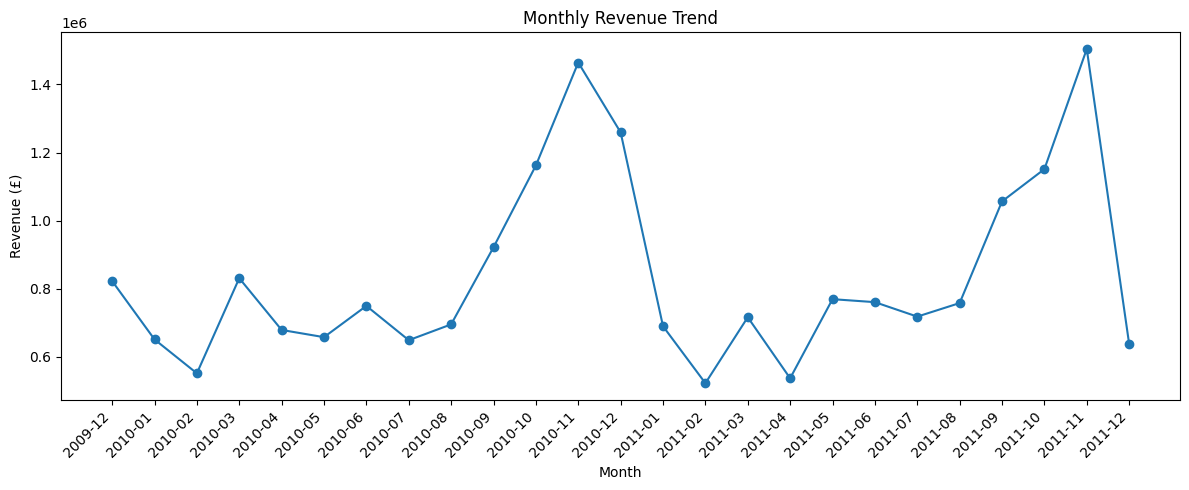

In [ ]:
import matplotlib.pyplot as plt

# Group by month, sum up revenue
monthly_revenue = (
    df_full.groupby("InvoiceYearMonth")["TotalPrice"]
    .sum()
    .reset_index()
    .sort_values("InvoiceYearMonth")
)

print(monthly_revenue)

# Plot it
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["InvoiceYearMonth"], monthly_revenue["TotalPrice"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Description
REGENCY CAKESTAND 3 TIER              344069.30
Manual                                340342.68
DOTCOM POSTAGE                        322657.48
WHITE HANGING HEART T-LIGHT HOLDER    266582.35
PAPER CRAFT , LITTLE BIRDIE           168469.60
JUMBO BAG RED RETROSPOT               150640.27
PARTY BUNTING                         149109.35
ASSORTED COLOUR BIRD ORNAMENT         131817.81
POSTAGE                               127597.42
PAPER CHAIN KIT 50'S CHRISTMAS        123002.89
Name: TotalPrice, dtype: float64


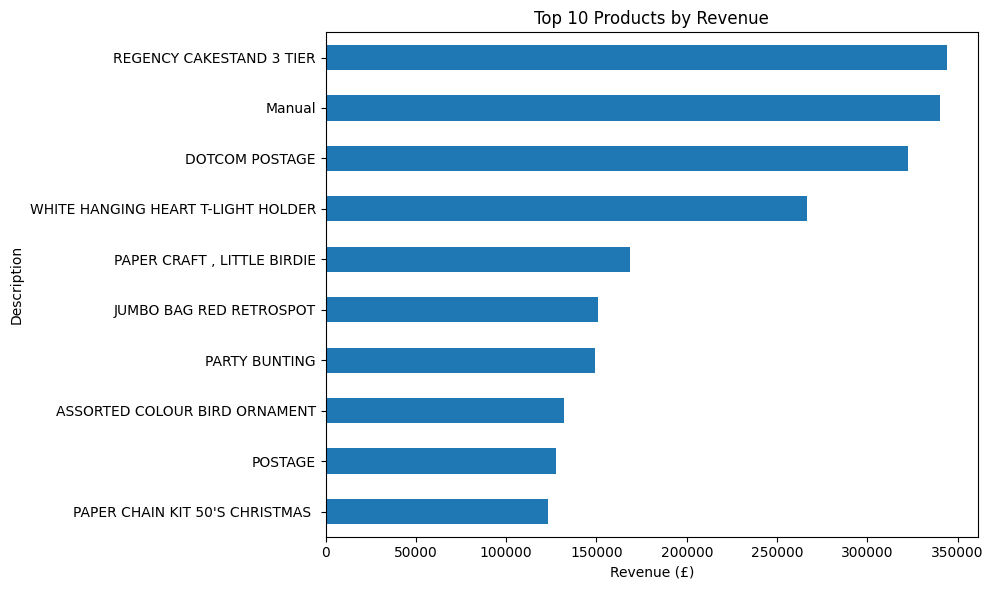

In [ ]:
top_products_revenue = (
    df_full.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_revenue)

# Plot it
plt.figure(figsize=(10, 6))
top_products_revenue.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.tight_layout()
plt.show()

Description
REGENCY CAKESTAND 3 TIER               344069.30
WHITE HANGING HEART T-LIGHT HOLDER     266582.35
PAPER CRAFT , LITTLE BIRDIE            168469.60
JUMBO BAG RED RETROSPOT                150640.27
PARTY BUNTING                          149109.35
ASSORTED COLOUR BIRD ORNAMENT          131817.81
PAPER CHAIN KIT 50'S CHRISTMAS         123002.89
CHILLI LIGHTS                           85157.56
MEDIUM CERAMIC TOP STORAGE JAR          81700.92
ROTATING SILVER ANGELS T-LIGHT HLDR     74380.07
Name: TotalPrice, dtype: float64


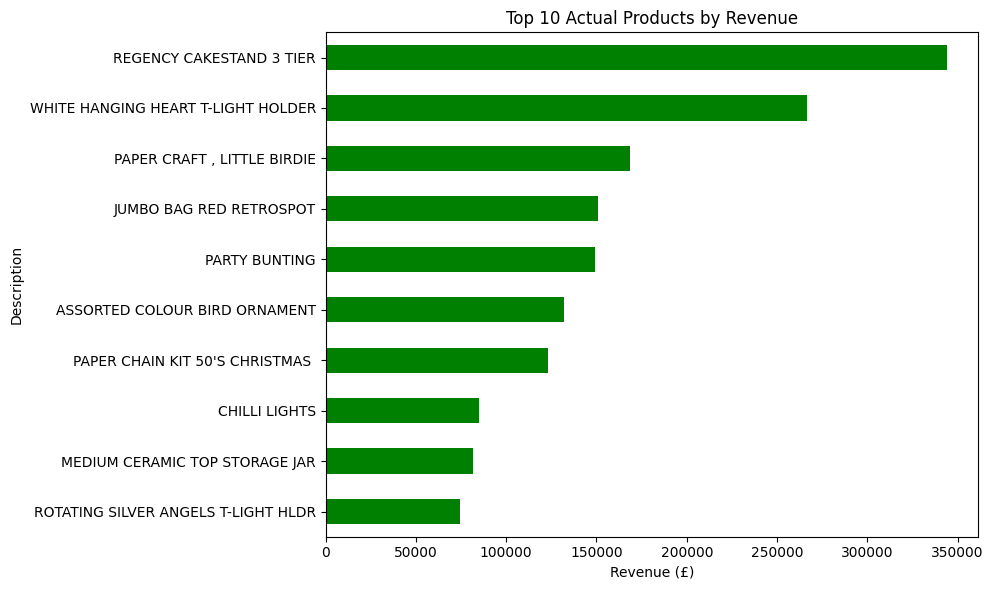

In [ ]:
# Common non-product entries in this dataset
non_products = ["Manual", "POSTAGE", "DOTCOM POSTAGE", "CARRIAGE", "SAMPLES"]

df_products_only = df_full[~df_full["Description"].isin(non_products)]

# Re-run top 10 on the cleaned product list
top_products_revenue_clean = (
    df_products_only.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_revenue_clean)

plt.figure(figsize=(10, 6))
top_products_revenue_clean.sort_values().plot(kind="barh", color="green")
plt.title("Top 10 Actual Products by Revenue")
plt.xlabel("Revenue (£)")
plt.tight_layout()
plt.show()

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     109898
WHITE HANGING HEART T-LIGHT HOLDER     96563
ASSORTED COLOUR BIRD ORNAMENT          81590
PAPER CRAFT , LITTLE BIRDIE            80995
JUMBO BAG RED RETROSPOT                79117
MEDIUM CERAMIC TOP STORAGE JAR         78033
BROCADE RING PURSE                     71394
PACK OF 60 PINK PAISLEY CAKE CASES     56625
60 TEATIME FAIRY CAKE CASES            54537
SMALL POPCORN HOLDER                   49922
Name: Quantity, dtype: int64


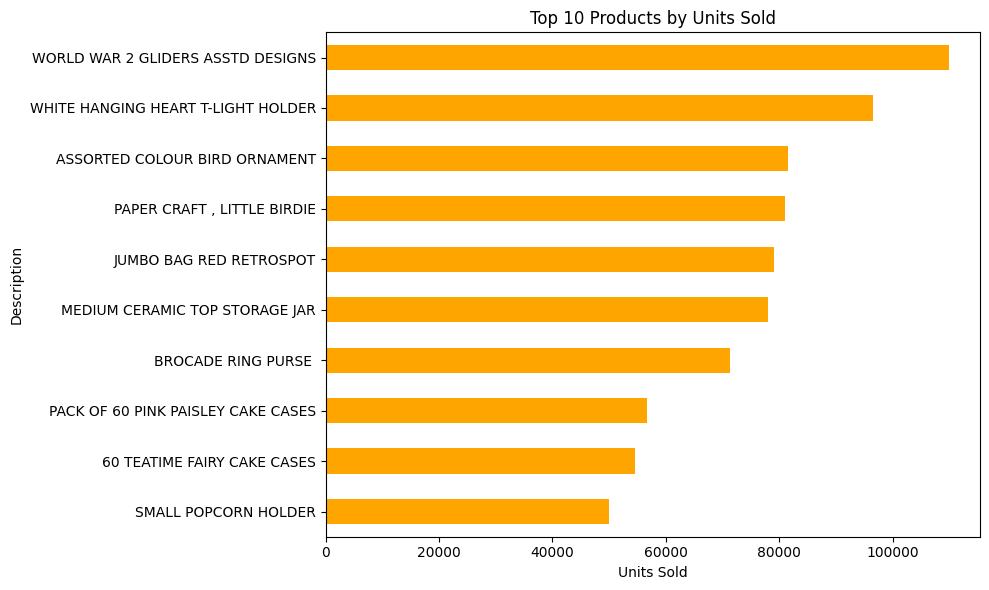

In [ ]:
top_products_volume = (
    df_products_only.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_volume)

plt.figure(figsize=(10, 6))
top_products_volume.sort_values().plot(kind="barh", color="orange")
plt.title("Top 10 Products by Units Sold")
plt.xlabel("Units Sold")
plt.tight_layout()
plt.show()

Country
United Kingdom    1.723268e+07
EIRE              6.301853e+05
Netherlands       5.499510e+05
Germany           3.884013e+05
France            3.168074e+05
Australia         1.684172e+05
Spain             9.878922e+04
Switzerland       9.424799e+04
Sweden            8.631914e+04
Denmark           6.856019e+04
Name: TotalPrice, dtype: float64


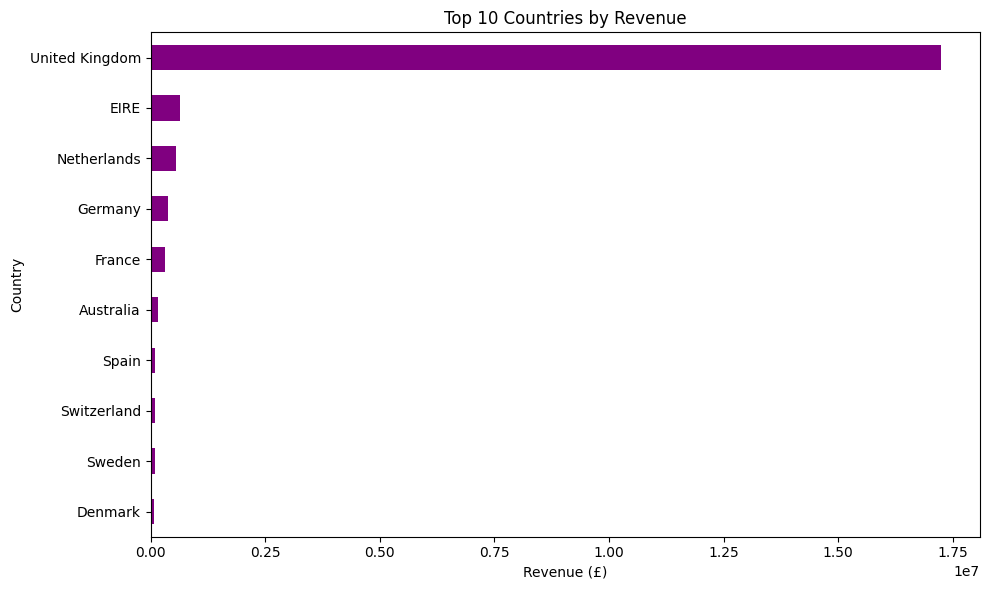

In [ ]:
# Revenue by country - top 10 overall
country_revenue = (
    df_products_only.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

print(country_revenue.head(10))

# Plot top 10 including UK
plt.figure(figsize=(10, 6))
country_revenue.head(10).sort_values().plot(kind="barh", color="purple")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.tight_layout()
plt.show()

Country
EIRE           630185.310
Netherlands    549951.010
Germany        388401.321
France         316807.440
Australia      168417.160
Spain           98789.220
Switzerland     94247.990
Sweden          86319.140
Denmark         68560.190
Belgium         57303.270
Name: TotalPrice, dtype: float64


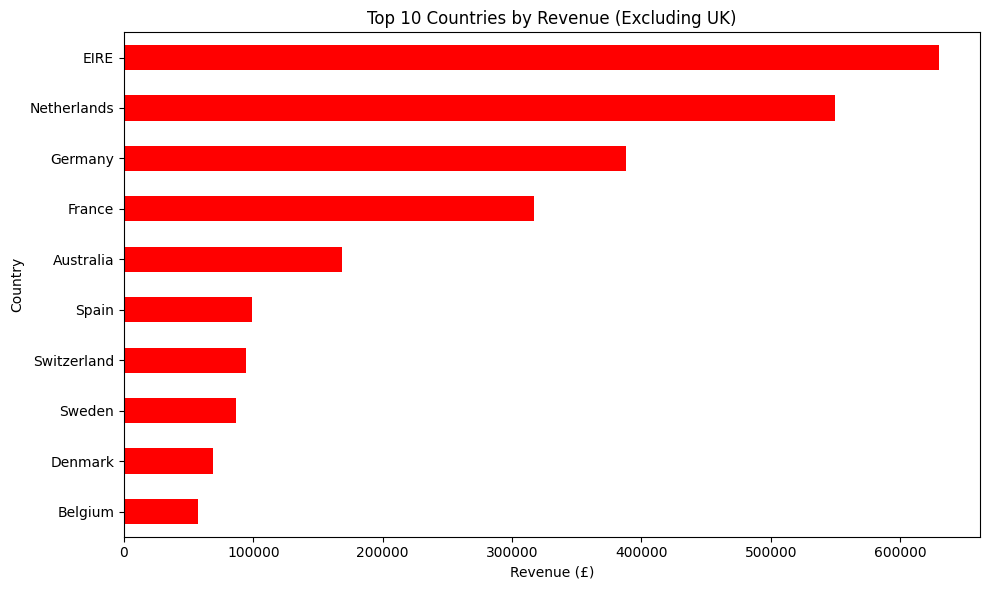

In [ ]:
country_revenue_no_uk = country_revenue.drop("United Kingdom", errors="ignore").head(10)

print(country_revenue_no_uk)

plt.figure(figsize=(10, 6))
country_revenue_no_uk.sort_values().plot(kind="barh", color="red")
plt.title("Top 10 Countries by Revenue (Excluding UK)")
plt.xlabel("Revenue (£)")
plt.tight_layout()
plt.show()

In [ ]:
import datetime as dt

# Reload the customer-only dataset if needed
# df_customers should already exist from Step 7

# Set a reference date - one day after the last transaction in the dataset
reference_date = df_customers["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)

# Group by customer and calculate R, F, M
rfm = df_customers.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

print(rfm.shape)
print(rfm.head(10))
print("\nSummary stats:")
print(rfm.describe())

Reference date: 2011-12-10 12:50:00
(5878, 4)
   Customer ID  Recency  Frequency  Monetary
0        12346      326         12  77556.46
1        12347        2          8   5633.32
2        12348       75          5   2019.40
3        12349       19          4   4428.69
4        12350      310          1    334.40
5        12351      375          1    300.93
6        12352       36         10   2849.84
7        12353      204          2    406.76
8        12354      232          1   1079.40
9        12355      214          2    947.61

Summary stats:
        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    3008.754787
std     1715.572666   209.338707    13.009406   14731.924115
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     345.115000
50%    15314.500000    96.000000     3.000000     887.390000
75%    16797.750

In [ ]:
# Recency: lower days = better = higher score, so we reverse the order (labels 5→1)
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1])

# Frequency: higher = better = higher score
# rank(method="first") avoids errors when many customers have identical values (e.g. many with Frequency=1)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])

# Monetary: higher = better = higher score
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5])

# Combine into a single RFM segment code, e.g. "555" = best possible customer
rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)

print(rfm.head(10))
print("\nScore distribution check:")
print(rfm["R_Score"].value_counts())
print(rfm["F_Score"].value_counts())
print(rfm["M_Score"].value_counts())

   Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0        12346      326         12  77556.46       2       5       5       255
1        12347        2          8   5633.32       5       4       5       545
2        12348       75          5   2019.40       3       4       4       344
3        12349       19          4   4428.69       5       3       5       535
4        12350      310          1    334.40       2       1       2       212
5        12351      375          1    300.93       2       1       2       212
6        12352       36         10   2849.84       4       5       4       454
7        12353      204          2    406.76       2       2       2       222
8        12354      232          1   1079.40       2       1       3       213
9        12355      214          2    947.61       2       2       3       223

Score distribution check:
R_Score
5    1188
4    1176
1    1175
2    1172
3    1167
Name: count, dtype: int64
F_Score
1    1176
3 

In [ ]:
def segment_customer(row):
    r, f = row["R_Score"], row["F_Score"]
    r, f = int(r), int(f)

    if r >= 4 and f >= 4:
        return "Champions"
    elif r >= 4 and f >= 2:
        return "Loyal Customers"
    elif r >= 4 and f == 1:
        return "New Customers"
    elif r == 3 and f >= 3:
        return "Potential Loyalists"
    elif r <= 2 and f >= 4:
        return "At Risk"
    elif r <= 2 and f <= 2:
        return "Lost"
    else:
        return "Needs Attention"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

# Count customers in each segment, and total revenue per segment
segment_summary = rfm.groupby("Segment").agg(
    CustomerCount=("Customer ID", "count"),
    TotalRevenue=("Monetary", "sum"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean")
).sort_values("TotalRevenue", ascending=False)

print(segment_summary)

                     CustomerCount  TotalRevenue  AvgRecency  AvgFrequency
Segment                                                                   
Champions                     1482  1.225919e+07   20.367072     15.657895
Potential Loyalists            782  2.053662e+06  108.696931      6.704604
At Risk                        353  1.121734e+06  344.212465      7.572238
Loyal Customers                714  8.204905e+05   25.756303      2.591036
Needs Attention                856  7.106610e+05  261.528037      2.245327
Lost                          1523  6.640272e+05  459.281024      1.252791
New Customers                  168  5.569362e+04   29.726190      1.000000


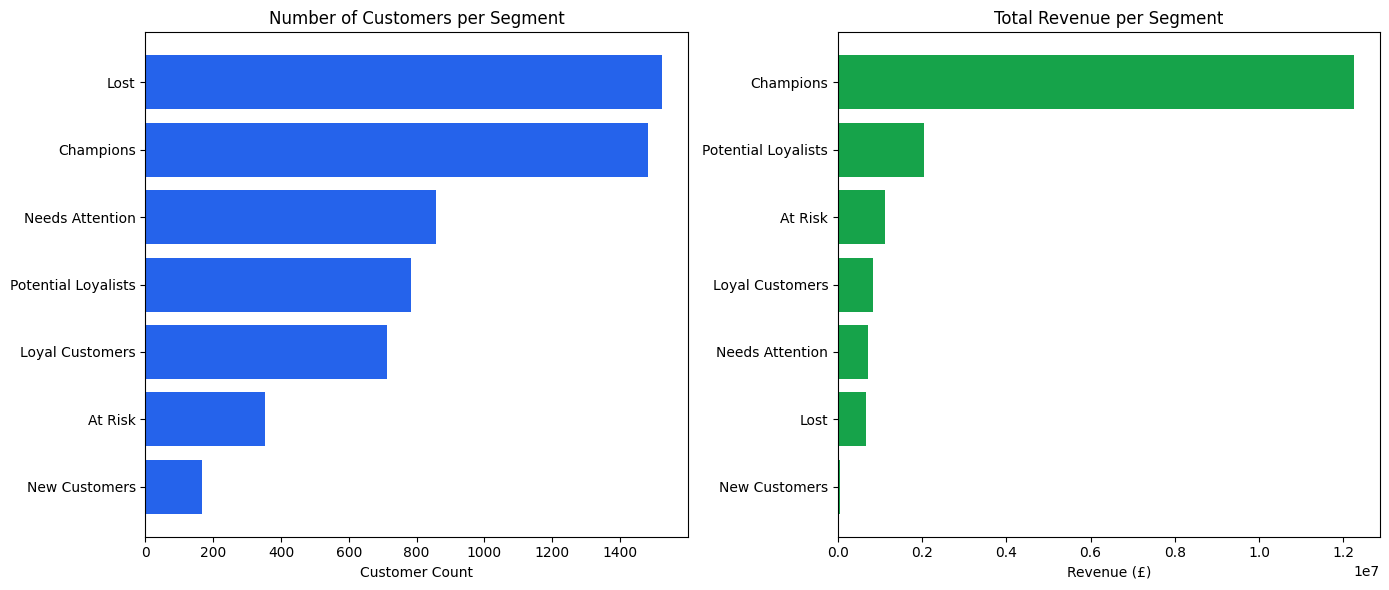

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Customer count by segment
segment_summary_sorted = segment_summary.sort_values("CustomerCount")
axes[0].barh(segment_summary_sorted.index, segment_summary_sorted["CustomerCount"], color="#2563eb")
axes[0].set_title("Number of Customers per Segment")
axes[0].set_xlabel("Customer Count")

# Chart 2: Revenue by segment
segment_summary_sorted_rev = segment_summary.sort_values("TotalRevenue")
axes[1].barh(segment_summary_sorted_rev.index, segment_summary_sorted_rev["TotalRevenue"], color="#16a34a")
axes[1].set_title("Total Revenue per Segment")
axes[1].set_xlabel("Revenue (£)")

plt.tight_layout()
plt.show()

In [ ]:
repeat_customers = (rfm["Frequency"] > 1).sum()
total_customers = len(rfm)
repeat_rate = repeat_customers / total_customers * 100

print(f"Customers with more than 1 order: {repeat_customers} out of {total_customers}")
print(f"Repeat purchase rate: {repeat_rate:.1f}%")

Customers with more than 1 order: 4255 out of 5878
Repeat purchase rate: 72.4%


In [ ]:
# Step 1: find each customer's first purchase month (their "cohort")
df_customers["OrderMonth"] = df_customers["InvoiceDate"].dt.to_period("M")
df_customers["CohortMonth"] = df_customers.groupby("Customer ID")["InvoiceDate"].transform("min").dt.to_period("M")

# Step 2: calculate how many months after their first purchase each transaction happened
df_customers["CohortIndex"] = (
    (df_customers["OrderMonth"].dt.year - df_customers["CohortMonth"].dt.year) * 12
    + (df_customers["OrderMonth"].dt.month - df_customers["CohortMonth"].dt.month)
)

# Step 3: count unique customers active in each CohortMonth x CohortIndex combination
cohort_data = (
    df_customers.groupby(["CohortMonth", "CohortIndex"])["Customer ID"]
    .nunique()
    .reset_index()
)

# Step 4: pivot into a matrix - rows = cohort month, columns = months since first purchase
cohort_pivot = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="Customer ID")

# Step 5: convert to retention % (divide every column by the first column - month 0)
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

print(retention.round(1))

CohortIndex     0     1     2     3     4     5     6     7     8     9   ...  \
CohortMonth                                                               ...   
2009-12      100.0  35.3  33.4  42.5  38.0  35.9  37.7  34.2  33.6  36.2  ...   
2010-01      100.0  20.6  31.1  30.5  26.4  30.0  25.8  23.0  27.9  31.9  ...   
2010-02      100.0  23.8  22.5  29.1  24.6  20.1  19.3  28.6  25.4  27.5  ...   
2010-03      100.0  19.0  23.0  24.2  23.3  20.3  24.6  30.2  27.5  10.8  ...   
2010-04      100.0  19.4  19.4  16.3  18.4  22.4  27.6  26.2  10.5  10.9  ...   
2010-05      100.0  15.7  16.9  17.3  17.7  25.6  21.3  12.6   5.9   8.3  ...   
2010-06      100.0  17.4  18.9  20.4  23.0  28.5  12.6   8.9   8.1  11.9  ...   
2010-07      100.0  15.6  18.3  29.6  29.0  14.0  11.3  14.5  14.5  11.3  ...   
2010-08      100.0  20.4  29.6  32.1  17.3  11.7   9.9  12.3  13.6  13.0  ...   
2010-09      100.0  22.6  23.5  12.3   9.1  10.3  13.6   9.9  12.8  13.2  ...   
2010-10      100.0  25.7  14

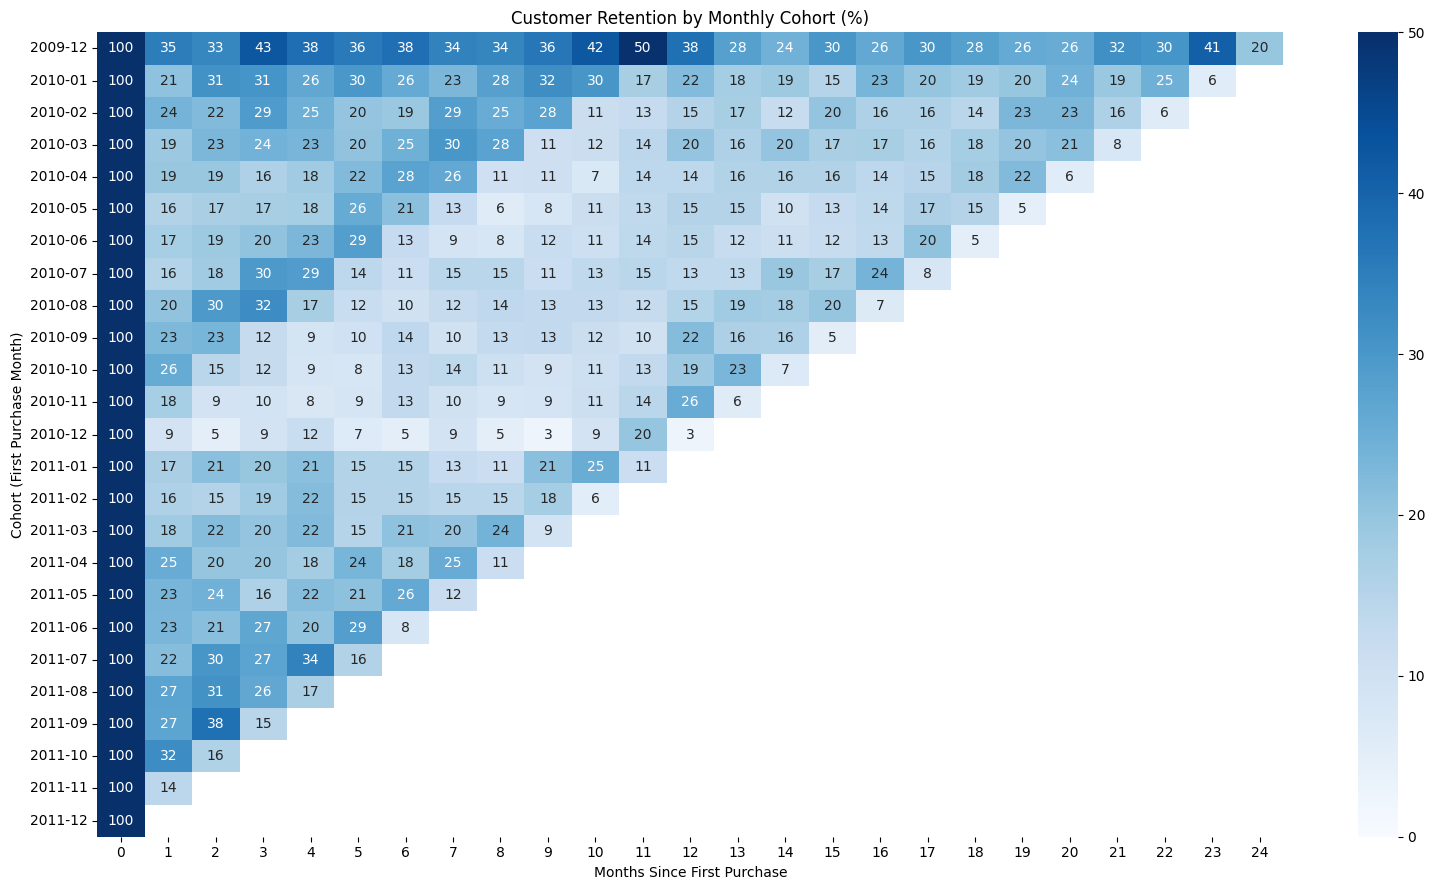

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 9))
sns.heatmap(retention, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=50)
plt.title("Customer Retention by Monthly Cohort (%)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort (First Purchase Month)")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Rebuild the monthly revenue series (in case it's not in memory)
monthly_revenue = (
    df_full.groupby("InvoiceYearMonth")["TotalPrice"]
    .sum()
    .reset_index()
    .sort_values("InvoiceYearMonth")
)

# IMPORTANT: drop the last month (Dec 2011) since we know it's a partial month, not a real dip
monthly_revenue_clean = monthly_revenue[monthly_revenue["InvoiceYearMonth"] != "2011-12"].copy()

# Create a simple numeric time index: 0, 1, 2, 3... for each month in order
monthly_revenue_clean["MonthIndex"] = range(len(monthly_revenue_clean))

# Fit a simple linear regression: MonthIndex -> Revenue
X = monthly_revenue_clean[["MonthIndex"]]
y = monthly_revenue_clean["TotalPrice"]

model = LinearRegression()
model.fit(X, y)

# Forecast the next 3 months
future_months = pd.DataFrame({"MonthIndex": range(len(monthly_revenue_clean), len(monthly_revenue_clean) + 3)})
future_predictions = model.predict(future_months)

print("Forecasted revenue for next 3 months:")
for i, pred in enumerate(future_predictions):
    print(f"Month +{i+1}: £{pred:,.2f}")

print(f"\nModel trend: £{model.coef_[0]:,.2f} change per month")
print(f"R² score (how well the line fits): {model.score(X, y):.3f}")

Forecasted revenue for next 3 months:
Month +1: £1,019,786.49
Month +2: £1,033,782.46
Month +3: £1,047,778.44

Model trend: £13,995.98 change per month
R² score (how well the line fits): 0.127


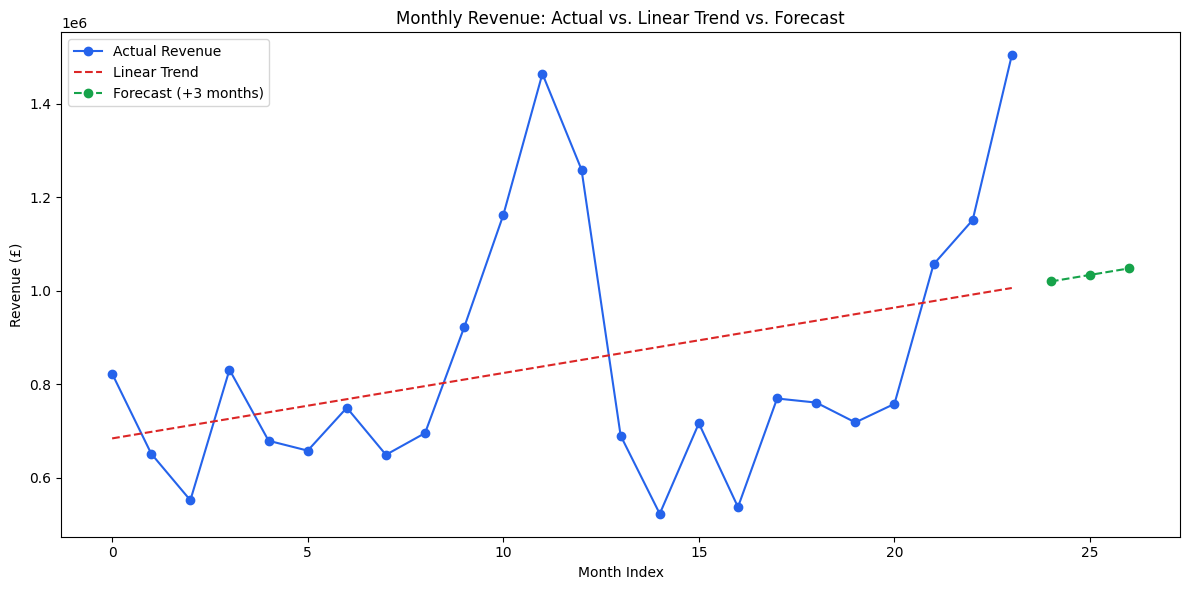

In [ ]:
plt.figure(figsize=(12, 6))

# Plot actual historical revenue
plt.plot(monthly_revenue_clean["MonthIndex"], monthly_revenue_clean["TotalPrice"],
         marker="o", label="Actual Revenue", color="#2563eb")

# Plot the fitted trend line
plt.plot(monthly_revenue_clean["MonthIndex"], model.predict(X),
         linestyle="--", label="Linear Trend", color="#dc2626")

# Plot the forecasted months
plt.plot(future_months["MonthIndex"], future_predictions,
         marker="o", linestyle="--", label="Forecast (+3 months)", color="#16a34a")

plt.title("Monthly Revenue: Actual vs. Linear Trend vs. Forecast")
plt.xlabel("Month Index")
plt.ylabel("Revenue (£)")
plt.legend()
plt.tight_layout()
plt.show()

                            Description  AvgSellingPrice  TotalUnits  \
5034        VINTAGE POST OFFICE CABINET        77.176000         134   
4419   SET/4 WHITE RETRO STORAGE CUBES         45.950182        1129   
1916            FUSCHIA RETRO BAR STOOL        37.559459         102   
3739                RED RETRO BAR STOOL        36.426216         101   
2162        HALL CABINET WITH 3 DRAWERS        47.238000         193   
811           CABIN BAG VINTAGE PAISLEY        25.856140         149   
733       BOTANICAL GARDENS WALL CLOCK         24.791807         262   
812         CABIN BAG VINTAGE RETROSPOT        25.828644         374   
1573  ENGLISH ROSE DESIGN QUILTED THROW        24.040602         816   
949        CHALKBOARD KITCHEN ORGANISER        29.387021         179   

      TotalRevenue  
5034       8562.52  
4419      43921.51  
1916       3672.35  
3739       3570.87  
2162       6567.17  
811        3447.20  
733        5843.92  
812        8224.63  
1573      17477.66

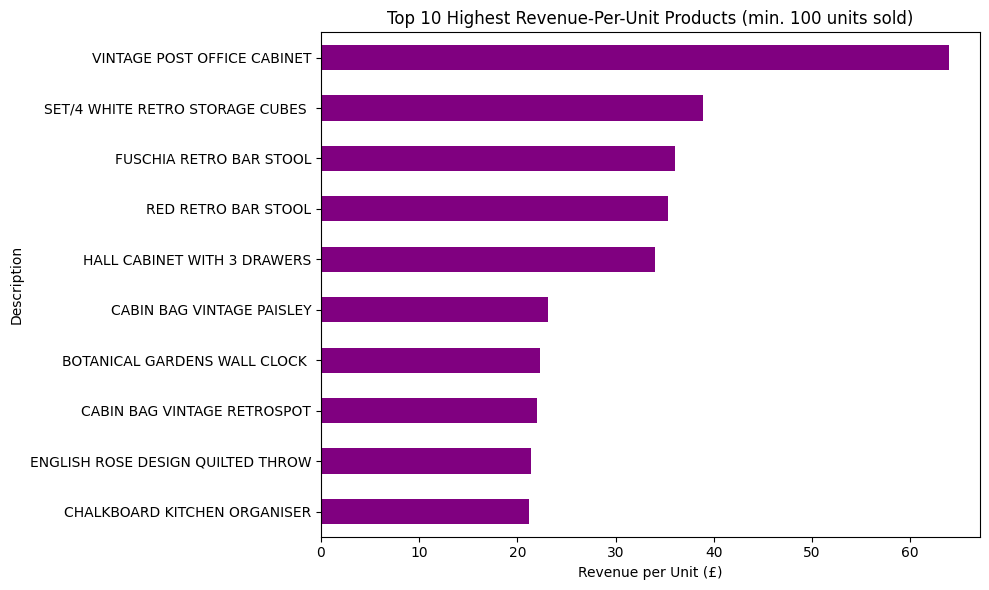

In [ ]:
non_products = ["Manual", "POSTAGE", "DOTCOM POSTAGE", "CARRIAGE", "SAMPLES"]
df_products_only = df_full[~df_full["Description"].isin(non_products)]

product_stats = df_products_only.groupby("Description").agg(
    TotalRevenue=("TotalPrice", "sum"),
    TotalUnits=("Quantity", "sum"),
    AvgSellingPrice=("Price", "mean")
).reset_index()

# Only look at products with meaningful volume, to avoid one-off noise
product_stats = product_stats[product_stats["TotalUnits"] >= 100]
product_stats["RevenuePerUnit"] = product_stats["TotalRevenue"] / product_stats["TotalUnits"]

top_efficient = product_stats.sort_values("RevenuePerUnit", ascending=False).head(10)
print(top_efficient[["Description", "AvgSellingPrice", "TotalUnits", "TotalRevenue"]])

plt.figure(figsize=(10, 6))
top_efficient.set_index("Description")["RevenuePerUnit"].sort_values().plot(kind="barh", color="purple")
plt.title("Top 10 Highest Revenue-Per-Unit Products (min. 100 units sold)")
plt.xlabel("Revenue per Unit (£)")
plt.tight_layout()
plt.show()

In [ ]:
reference_date = df_customers["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm_simple = df_customers.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("Invoice", "nunique")
).reset_index()

# Define churned = no purchase in the last 180 days (6 months)
churn_threshold_days = 180
rfm_simple["Churned"] = rfm_simple["Recency"] > churn_threshold_days

churn_rate = rfm_simple["Churned"].mean() * 100
active_rate = 100 - churn_rate

print(f"Churned customers: {rfm_simple['Churned'].sum()} ({churn_rate:.1f}%)")
print(f"Active customers: {(~rfm_simple['Churned']).sum()} ({active_rate:.1f}%)")

Churned customers: 2400 (40.8%)
Active customers: 3478 (59.2%)
